# Painel de Vendas com Visualização de Dados
## Passo 1 — Preparação e Importação de Dados

### 1.1 Importar as bibliotecas

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Carregar o `vendas.csv`
Como o arquivo é fictício, a célula abaixo cria o dataset (colunas: data, loja, produto, quantidade, preco_unitario) e salva em `vendas.csv`. Se você já tiver o arquivo, ele é só carregado.

In [66]:
import os

if not os.path.exists('vendas.csv'):
    np.random.seed(42)
    n = 200
    precos = {'Camiseta': 49.90, 'Calça': 129.90, 'Tênis': 249.90, 'Boné': 39.90}

    dados = pd.DataFrame({
        'data': pd.date_range('2025-01-01', periods=n, freq='D').strftime('%Y-%m-%d'),
        'loja': np.random.choice(['Loja Centro', 'Loja Norte', 'Loja Sul'], n),
        'produto': np.random.choice(list(precos.keys()), n),
        'quantidade': np.random.randint(1, 11, n),
    })
    dados['preco_unitario'] = dados['produto'].map(precos)
    dados.to_csv('vendas.csv', index=False)

df = pd.read_csv('vendas.csv')
df.head()

,data,loja,produto,quantidade,preco_unitario
0,2025-01-01,Loja Sul,Boné,1,39.9
1,2025-01-02,Loja Centro,Camiseta,1,49.9
2,2025-01-03,Loja Sul,Calça,5,129.9
3,2025-01-04,Loja Sul,Camiseta,6,49.9
4,2025-01-05,Loja Centro,Calça,3,129.9


### 1.3 Converter a coluna `data` para datetime

In [67]:
df['data'] = pd.to_datetime(df['data'])
df.dtypes

data              datetime64[us]
loja                         str
produto                      str
quantidade                 int64
preco_unitario           float64
dtype: object

### 1.4 Criar a coluna `faturamento` (quantidade × preço unitário)

In [68]:
df['faturamento'] = df['quantidade'] * df['preco_unitario']
df.head()

,data,loja,produto,quantidade,preco_unitario,faturamento
0,2025-01-01,Loja Sul,Boné,1,39.9,39.9
1,2025-01-02,Loja Centro,Camiseta,1,49.9,49.9
2,2025-01-03,Loja Sul,Calça,5,129.9,649.5
3,2025-01-04,Loja Sul,Camiseta,6,49.9,299.4
4,2025-01-05,Loja Centro,Calça,3,129.9,389.7


### 1.5 Verificar a integridade do dataset

In [69]:
# Tipos de dados e quantidade de valores não nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            200 non-null    datetime64[us]
 1   loja            200 non-null    str           
 2   produto         200 non-null    str           
 3   quantidade      200 non-null    int64         
 4   preco_unitario  200 non-null    float64       
 5   faturamento     200 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 9.5 KB


In [70]:
# Valores ausentes por coluna
df.isnull().sum()

data              0
loja              0
produto           0
quantidade        0
preco_unitario    0
faturamento       0
dtype: int64

In [71]:
# Estatísticas descritivas
df.describe()

,data,quantidade,preco_unitario,faturamento
count,200,200.000000,200.000000,200.000000
mean,2025-04-10 12:00:00,5.550000,109.850000,615.045000
min,2025-01-01 00:00:00,1.000000,39.900000,39.900000
25%,2025-02-19 18:00:00,3.000000,39.900000,199.500000
50%,2025-04-10 12:00:00,5.000000,49.900000,359.100000
75%,2025-05-30 06:00:00,8.000000,129.900000,779.400000
max,2025-07-19 00:00:00,10.000000,249.900000,2499.000000
std,NaN,3.055188,83.962767,628.810146


In [72]:
df.isnull().sum()


data              0
loja              0
produto           0
quantidade        0
preco_unitario    0
faturamento       0
dtype: int64

In [73]:
mediaQuantidade = df['quantidade'].mean()  
mediaPrecoUnitario = df['preco_unitario'].mean()

In [74]:
df.fillna({'quantidade': mediaQuantidade, 'preco_unitario': mediaPrecoUnitario}, inplace=True)

,data,loja,produto,quantidade,preco_unitario,faturamento
0,2025-01-01,Loja Sul,Boné,1,39.9,39.9
1,2025-01-02,Loja Centro,Camiseta,1,49.9,49.9
2,2025-01-03,Loja Sul,Calça,5,129.9,649.5
3,2025-01-04,Loja Sul,Camiseta,6,49.9,299.4
4,2025-01-05,Loja Centro,Calça,3,129.9,389.7
...,...,...,...,...,...,...
195,2025-07-15,Loja Norte,Camiseta,2,49.9,99.8
196,2025-07-16,Loja Sul,Boné,1,39.9,39.9
197,2025-07-17,Loja Sul,Tênis,7,249.9,1749.3
198,2025-07-18,Loja Norte,Boné,8,39.9,319.2


In [75]:
df['faturamento'].groupby(df['loja']).sum().sort_values(ascending=False)

loja
Loja Centro    47672.0
Loja Sul       39819.6
Loja Norte     35517.4
Name: faturamento, dtype: float64

In [76]:
ticket_medio = df.groupby('loja')['faturamento'].sum() / df.groupby('loja')['quantidade'].sum()
ticket_medio.sort_values(ascending=False)

loja
Loja Centro    125.452632
Loja Norte     108.949080
Loja Sul        98.563366
dtype: float64

In [77]:
df.sort_values('quantidade', ascending=False).head(5)

,data,loja,produto,quantidade,preco_unitario,faturamento
40,2025-02-10,Loja Centro,Boné,10,39.9,399.0
45,2025-02-15,Loja Sul,Boné,10,39.9,399.0
63,2025-03-05,Loja Norte,Boné,10,39.9,399.0
38,2025-02-08,Loja Centro,Tênis,10,249.9,2499.0
31,2025-02-01,Loja Sul,Boné,10,39.9,399.0


In [78]:
mes_maior_faturamentoConta = df.groupby(df['data'].dt.month)['faturamento'].sum().idxmax()
mes_maior_faturamentoNome = pd.to_datetime(f'2025-{mes_maior_faturamentoConta}-01').strftime('%D')
mes_maior_faturamentoNome

'03/01/25'

In [79]:
df['mes'] = df['data'].dt.month
df

,data,loja,produto,quantidade,preco_unitario,faturamento,mes
0,2025-01-01,Loja Sul,Boné,1,39.9,39.9,1
1,2025-01-02,Loja Centro,Camiseta,1,49.9,49.9,1
2,2025-01-03,Loja Sul,Calça,5,129.9,649.5,1
3,2025-01-04,Loja Sul,Camiseta,6,49.9,299.4,1
4,2025-01-05,Loja Centro,Calça,3,129.9,389.7,1
...,...,...,...,...,...,...,...
195,2025-07-15,Loja Norte,Camiseta,2,49.9,99.8,7
196,2025-07-16,Loja Sul,Boné,1,39.9,39.9,7
197,2025-07-17,Loja Sul,Tênis,7,249.9,1749.3,7
198,2025-07-18,Loja Norte,Boné,8,39.9,319.2,7


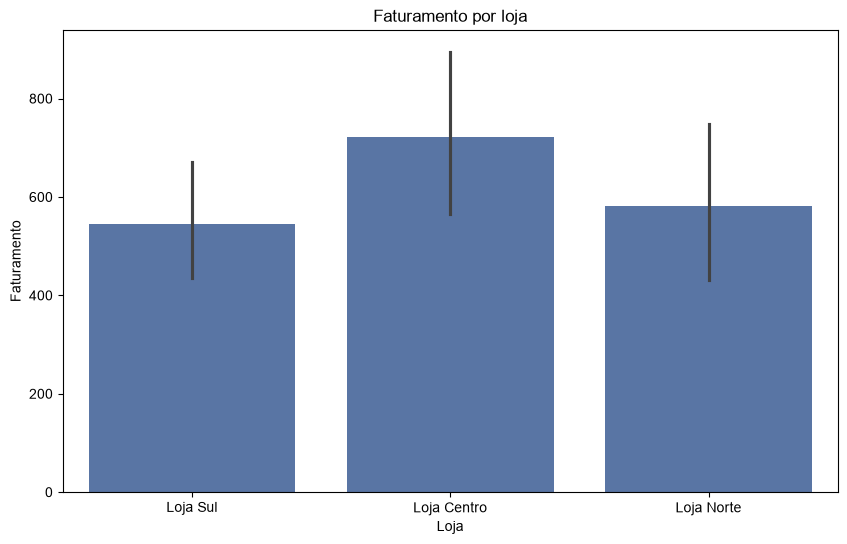

In [90]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='loja', y='faturamento', data=df)
sns.set_palette("deep")
sns.set_style("whitegrid")
plt.title('Faturamento por loja')
plt.xlabel('Loja')
plt.ylabel('Faturamento')
plt.show()

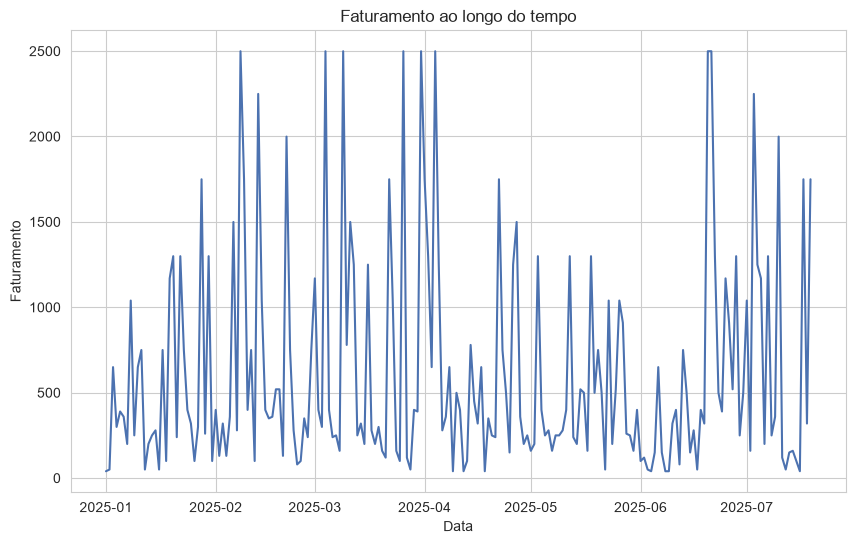

In [91]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(df.groupby('data')['faturamento'].sum())
sns.set_palette("deep")
sns.set_style("whitegrid")
plt.title('Faturamento ao longo do tempo')
plt.xlabel('Data')  
plt.ylabel('Faturamento')
plt.show()

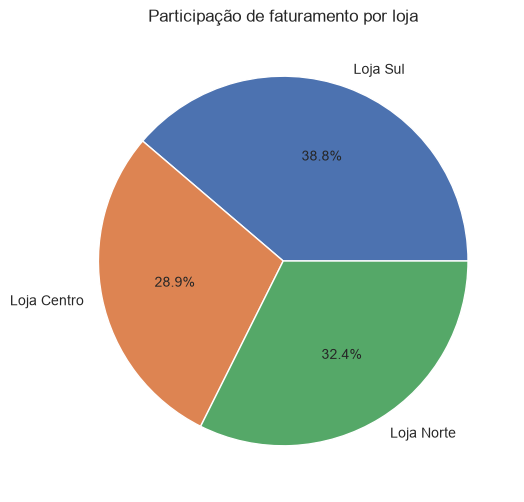

In [92]:
plt.figure(figsize=(10, 6))
plt.pie(df.groupby('loja')['faturamento'].sum(), labels=df['loja'].unique(), autopct='%1.1f%%')
plt.title('Participação de faturamento por loja')
sns.set_palette("deep")
sns.set_style("whitegrid")
plt.show()

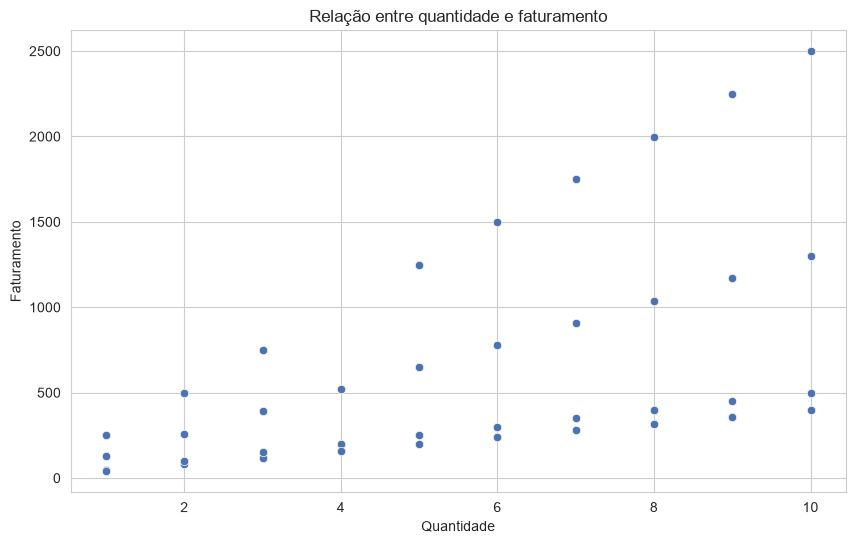

In [93]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='quantidade', y='faturamento', data=df)
plt.title('Relação entre quantidade e faturamento')
sns.set_palette("deep")
sns.set_style("whitegrid")
plt.xlabel('Quantidade')
plt.ylabel('Faturamento')
plt.show()

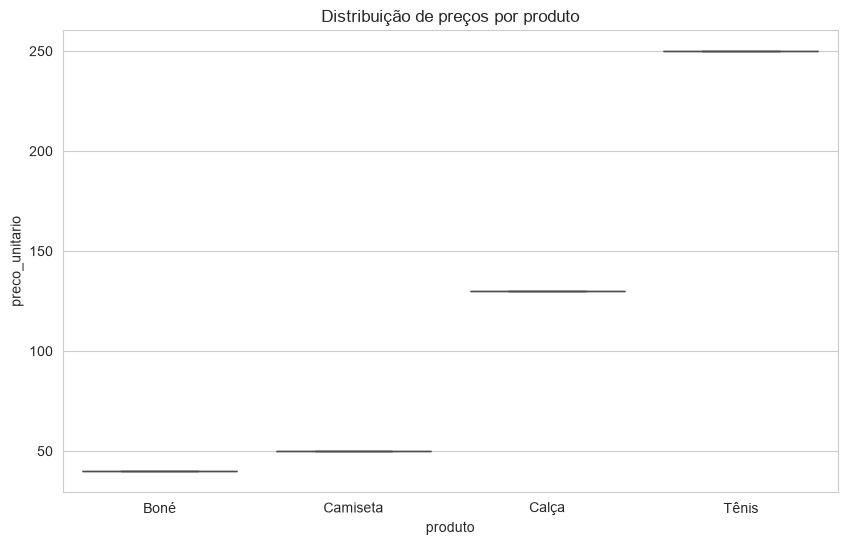

In [94]:
plt.figure(figsize=(10, 6))
sns.boxplot( data=df,x='produto', y='preco_unitario')
sns.set_palette("deep")
sns.set_style("whitegrid")
plt.title('Distribuição de preços por produto')
plt.show()

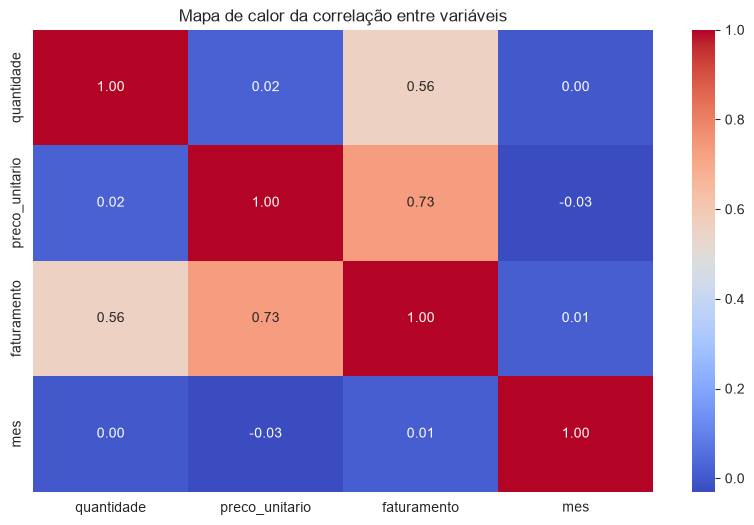

In [95]:
correlacao = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.set_palette("deep")
sns.set_style("whitegrid")
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de calor da correlação entre variáveis')
plt.show()